# 02 — Préprocessing professionnel  
## House Prices: Advanced Regression Techniques

Ce notebook prépare le **jeu de données Stage 1** pour la suite du pipeline Kaggle.

Objectif principal : transformer les données brutes en une base propre, cohérente et exploitable par le notebook de feature engineering.

Ce notebook réalise :

1. chargement local des fichiers `train.csv`, `test.csv`, `sample_submission.csv` ;
2. suppression des outliers les plus évidents ;
3. transformation logarithmique de la cible `SalePrice` ;
4. concaténation train/test pour garantir un traitement identique ;
5. imputation intelligente des valeurs manquantes ;
6. encodage ordinal des variables qualitatives ordonnées ;
7. contrôles qualité avant sauvegarde.

Le fichier généré à la fin est :

```text
house_prices_stage1_preprocessed.pkl
```

> Important : les cellules d'analyse ajoutées ici servent à comprendre et justifier le preprocessing. Elles ne changent pas la logique du modèle final.

## 1. Configuration générale

On importe uniquement les bibliothèques nécessaires pour cette étape : manipulation des données, visualisation légère et sauvegarde locale.

In [1]:
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Affichage plus confortable dans le notebook
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Constantes conservées depuis le notebook original
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

N_SPLITS = 10
LINEAR_CV_FOLDS = 3
STRATIFIED_PRICE_FOLDS = True
OPTUNA_N_TRIALS = 100

print('Configuration prête.')
print('Date d’exécution :', datetime.now().strftime('%Y-%m-%d %H:%M'))

Configuration prête.
Date d’exécution : 2026-05-14 09:05


## 2. Chargement local des données



In [2]:
DATA_DIR = None
REQUIRED_FILES = ['train.csv', 'test.csv', 'sample_submission.csv']

def folder_has_required_files(folder):
    """Vérifie qu'un dossier contient les trois fichiers Kaggle nécessaires."""
    folder = Path(folder)
    return all((folder / f).exists() for f in REQUIRED_FILES)

def find_data_dir(manual_dir=None):
    """Trouve automatiquement le dossier contenant les fichiers de la compétition."""
    if manual_dir is not None:
        manual_dir = Path(manual_dir).expanduser().resolve()
        if folder_has_required_files(manual_dir):
            return manual_dir
        raise FileNotFoundError(
            f'DATA_DIR={manual_dir} ne contient pas train.csv, test.csv et sample_submission.csv.'
        )

    current = Path.cwd().resolve()
    priority_dirs = [
        current,
        current / 'data',
        current / 'input',
        current / 'dataset',
        current / 'datasets',
        current / 'house-prices-advanced-regression-techniques',
    ]

    for folder in priority_dirs:
        if folder.exists() and folder_has_required_files(folder):
            return folder

    # Recherche locale dans le projet seulement.
    try:
        for train_path in current.rglob('train.csv'):
            folder = train_path.parent
            if folder_has_required_files(folder):
                return folder
    except Exception:
        pass

    raise FileNotFoundError(
        'Impossible de trouver train.csv, test.csv et sample_submission.csv. '
        'Place-les dans le même dossier que le notebook, dans ./data, '
        'ou renseigne DATA_DIR manuellement.'
    )

DATA_DIR = find_data_dir(DATA_DIR)
print('Dossier des données utilisé :', DATA_DIR)

train_raw = pd.read_csv(DATA_DIR / 'train.csv')
test_raw  = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

resume_chargement = pd.DataFrame({
    'Dataset': ['train_raw', 'test_raw', 'sample_submission'],
    'Lignes': [train_raw.shape[0], test_raw.shape[0], sample_submission.shape[0]],
    'Colonnes': [train_raw.shape[1], test_raw.shape[1], sample_submission.shape[1]],
})

display(resume_chargement)

Dossier des données utilisé : C:\Users\souma\OneDrive\Bureau\proj ML\projet\final\data


,Dataset,Lignes,Colonnes
0,train_raw,1460,81
1,test_raw,1459,80
2,sample_submission,1459,2


### Interprétation

- `train_raw` contient la variable cible `SalePrice`.
- `test_raw` ne contient pas `SalePrice` : c'est ce fichier qui servira à générer la soumission Kaggle.
- Le preprocessing doit être appliqué de façon cohérente sur train et test pour éviter des colonnes différentes après transformation.

## 3. Diagnostic initial des données

Avant de nettoyer, on regarde rapidement la structure, les valeurs manquantes et la distribution de `SalePrice`.

In [3]:
def quick_schema_report(df, name):
    """Résumé simple des types de variables et des valeurs manquantes."""
    return pd.Series({
        'dataset': name,
        'lignes': df.shape[0],
        'colonnes': df.shape[1],
        'colonnes_numériques': df.select_dtypes(include=[np.number]).shape[1],
        'colonnes_catégorielles': df.select_dtypes(exclude=[np.number]).shape[1],
        'valeurs_manquantes_total': int(df.isna().sum().sum()),
        'colonnes_avec_NA': int((df.isna().sum() > 0).sum()),
    })

schema_report = pd.DataFrame([
    quick_schema_report(train_raw, 'train_raw'),
    quick_schema_report(test_raw, 'test_raw')
])

display(schema_report)
display(train_raw['SalePrice'].describe().to_frame('SalePrice'))

,dataset,lignes,colonnes,colonnes_numériques,colonnes_catégorielles,valeurs_manquantes_total,colonnes_avec_NA
0,train_raw,1460,81,38,43,7829,19
1,test_raw,1459,80,37,43,7878,33


,SalePrice
count,"1,460.000"
mean,"180,921.196"
std,"79,442.503"
min,"34,900.000"
25%,"129,975.000"
50%,"163,000.000"
75%,"214,000.000"
max,"755,000.000"


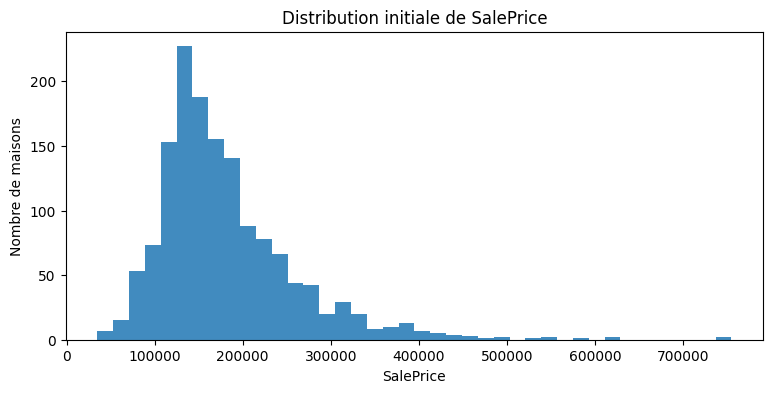

Interprétation automatique :
- Prix moyen : $180,921
- Prix médian : $163,000
- Asymétrie approximative : 1.88
- Une forte asymétrie positive signifie que quelques maisons très chères tirent la distribution vers la droite.


In [4]:
# Visualisation de la distribution initiale de SalePrice.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_raw['SalePrice'], bins=40, alpha=0.85)
ax.set_title('Distribution initiale de SalePrice')
ax.set_xlabel('SalePrice')
ax.set_ylabel('Nombre de maisons')
plt.show()

print('Interprétation automatique :')
print(f"- Prix moyen : ${train_raw['SalePrice'].mean():,.0f}")
print(f"- Prix médian : ${train_raw['SalePrice'].median():,.0f}")
print(f"- Asymétrie approximative : {train_raw['SalePrice'].skew():.2f}")
print('- Une forte asymétrie positive signifie que quelques maisons très chères tirent la distribution vers la droite.')

## 4. Détection et suppression ciblée des outliers Ames Housing



```python
GrLivArea > 4000 et SalePrice < 200000
```

Ces points correspondent à de très grandes maisons vendues anormalement peu cher. Ils peuvent fausser la relation entre surface habitable et prix, surtout pour les modèles linéaires et les modèles d'ensemble.

On garde cette règle **ciblée** pour éviter de supprimer trop d'observations utiles.


In [5]:
# Copie de travail : on ne modifie jamais directement train_raw/test_raw.
train = train_raw.copy()
test  = test_raw.copy()

# Amélioration score : suppression ciblée des 2 outliers Ames Housing les plus connus.
# Règle conservatrice : grande surface habitable mais prix très faible.
outlier_mask = (
    (train['GrLivArea'] > 4000) &
    (train['SalePrice'] < 200_000)
)

outliers_detected = train.loc[outlier_mask, ['Id', 'GrLivArea', 'LotArea', 'OverallQual', 'SalePrice']].copy()

print('Stratégie outliers : GrLivArea > 4000 et SalePrice < 200000')
print('Nombre d’outliers détectés :', int(outlier_mask.sum()))
display(outliers_detected)


Stratégie outliers : GrLivArea > 4000 et SalePrice < 200000
Nombre d’outliers détectés : 2


,Id,GrLivArea,LotArea,OverallQual,SalePrice
523,524,4676,40094,10,184750
1298,1299,5642,63887,10,160000


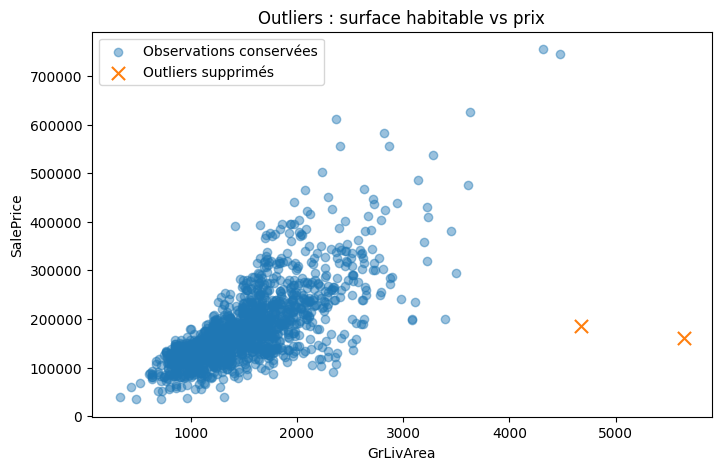

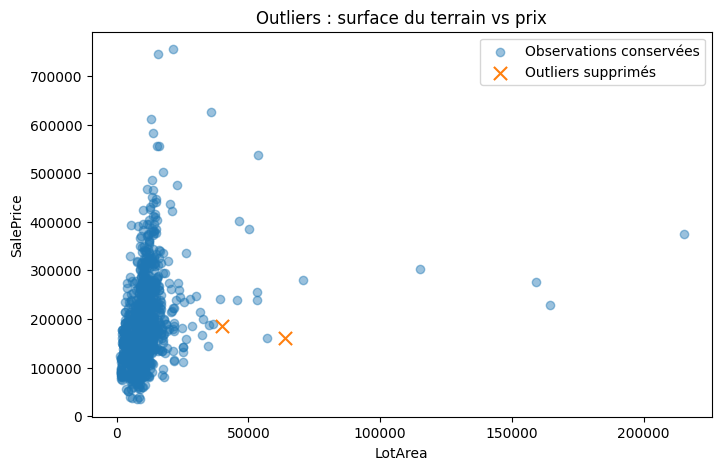

In [6]:
# Plot 1 : relation GrLivArea / SalePrice avant suppression.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train.loc[~outlier_mask, 'GrLivArea'], train.loc[~outlier_mask, 'SalePrice'], alpha=0.45, label='Observations conservées')
if outlier_mask.sum() > 0:
    ax.scatter(train.loc[outlier_mask, 'GrLivArea'], train.loc[outlier_mask, 'SalePrice'], marker='x', s=90, label='Outliers supprimés')
ax.set_title('Outliers : surface habitable vs prix')
ax.set_xlabel('GrLivArea')
ax.set_ylabel('SalePrice')
ax.legend()
plt.show()

# Plot 2 : relation LotArea / SalePrice avant suppression.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train.loc[~outlier_mask, 'LotArea'], train.loc[~outlier_mask, 'SalePrice'], alpha=0.45, label='Observations conservées')
if outlier_mask.sum() > 0:
    ax.scatter(train.loc[outlier_mask, 'LotArea'], train.loc[outlier_mask, 'SalePrice'], marker='x', s=90, label='Outliers supprimés')
ax.set_title('Outliers : surface du terrain vs prix')
ax.set_xlabel('LotArea')
ax.set_ylabel('SalePrice')
ax.legend()
plt.show()

In [ ]:

print('Lignes train avant suppression :', train.shape[0])
print('Outliers supprimés          :', int(outlier_mask.sum()))

train = train.loc[~outlier_mask].reset_index(drop=True)

print('Lignes train après suppression:', train.shape[0])


Lignes train avant suppression : 1460
Outliers supprimés          : 2
Lignes train après suppression: 1458


### Interprétation

La suppression d'outliers évite que le modèle apprenne des relations peu réalistes, par exemple :

> très grande maison → prix faible

Ces points peuvent fortement influencer la régression et dégrader le score RMSE sur Kaggle.

## 5. Préparation de la cible et concaténation train/test

On prépare :

- `y` : cible transformée avec `log1p(SalePrice)` ;
- `features` : concaténation de train et test sans `SalePrice` et sans `Id`.

La concaténation garantit que train et test reçoivent exactement les mêmes traitements.

In [ ]:
train_ID = train['Id'].copy()
test_ID  = test['Id'].copy()

# Transformation logarithmique de la cible.
y = np.log1p(train['SalePrice']).reset_index(drop=True)
train_features = train.drop(columns=['SalePrice'])
test_features  = test.copy()

n_train  = train_features.shape[0]
features = pd.concat([train_features, test_features], axis=0, ignore_index=True)
features = features.drop(columns=['Id'])

print('Shape train_features :', train_features.shape)
print('Shape test_features  :', test_features.shape)
print('Shape features concat:', features.shape)
print('Shape y              :', y.shape)

Shape train_features : (1458, 80)
Shape test_features  : (1459, 80)
Shape features concat: (2917, 79)
Shape y              : (1458,)


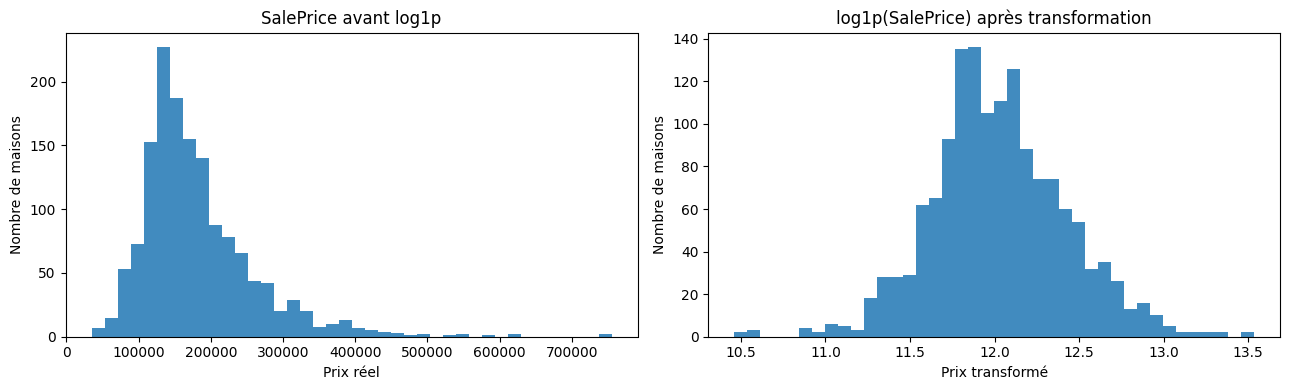

Interprétation automatique :
- Skewness avant log1p : 1.88
- Skewness après log1p : 0.12
- Une distribution plus symétrique aide souvent Ridge, Lasso et ElasticNet.


In [9]:
# Effet de la transformation log1p sur la cible.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['SalePrice'], bins=40, alpha=0.85)
axes[0].set_title('SalePrice avant log1p')
axes[0].set_xlabel('Prix réel')
axes[0].set_ylabel('Nombre de maisons')

axes[1].hist(y, bins=40, alpha=0.85)
axes[1].set_title('log1p(SalePrice) après transformation')
axes[1].set_xlabel('Prix transformé')
axes[1].set_ylabel('Nombre de maisons')

plt.tight_layout()
plt.show()

print('Interprétation automatique :')
print(f"- Skewness avant log1p : {train['SalePrice'].skew():.2f}")
print(f"- Skewness après log1p : {pd.Series(y).skew():.2f}")
print("- Une distribution plus symétrique aide souvent Ridge, Lasso et ElasticNet.")

## 6. Analyse des valeurs manquantes avant preprocessing

Les valeurs manquantes ne signifient pas toujours la même chose.

Exemples :

- `PoolQC` manquant signifie souvent **pas de piscine** ;
- `GarageType` manquant signifie souvent **pas de garage** ;
- `BsmtQual` manquant signifie souvent **pas de sous-sol** ;
- `LotFrontage` manquant est une vraie valeur numérique à estimer.

,variable,missing_count,missing_pct,dtype
0,PoolQC,2908,99.691,str
1,MiscFeature,2812,96.400,str
2,Alley,2719,93.212,str
3,Fence,2346,80.425,str
4,MasVnrType,1766,60.542,str
5,FireplaceQu,1420,48.680,str
6,LotFrontage,486,16.661,float64
7,GarageQual,159,5.451,str
8,GarageYrBlt,159,5.451,float64
9,GarageCond,159,5.451,str


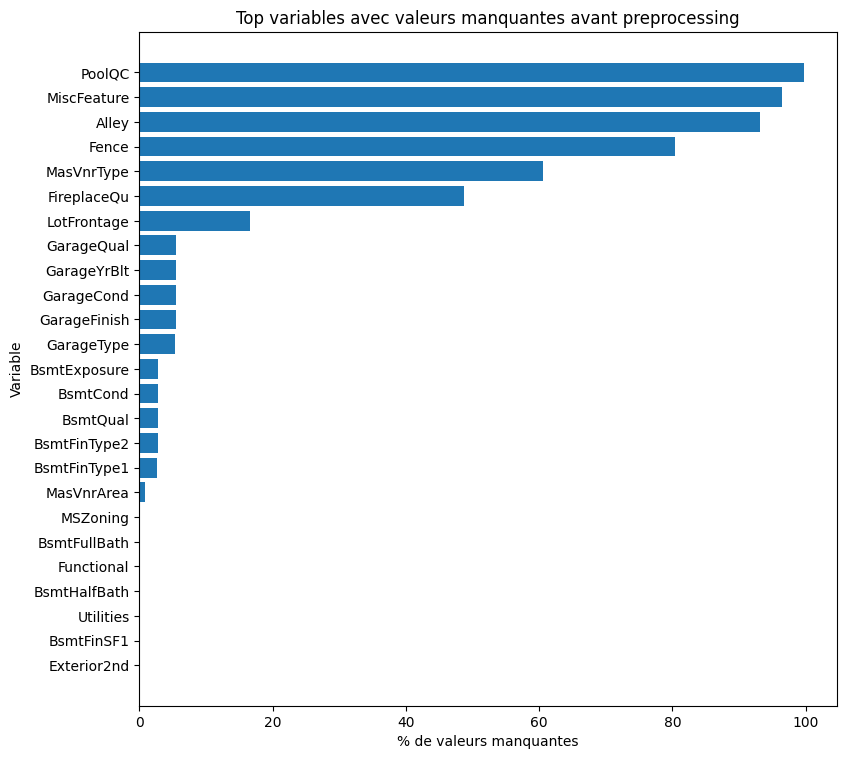

In [10]:
def missing_table(df):
    """Tableau propre des valeurs manquantes."""
    miss = df.isna().sum()
    pct = miss / len(df) * 100
    out = pd.DataFrame({
        'variable': miss.index,
        'missing_count': miss.values,
        'missing_pct': pct.values,
        'dtype': [str(df[c].dtype) for c in miss.index]
    })
    out = out[out['missing_count'] > 0].sort_values('missing_count', ascending=False)
    return out.reset_index(drop=True)

def plot_missing_top(df, title, top_n=25):
    """Barplot horizontal des variables avec le plus de valeurs manquantes."""
    miss = missing_table(df).head(top_n)
    if miss.empty:
        print('Aucune valeur manquante à afficher.')
        return
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(miss))))
    ax.barh(miss['variable'][::-1], miss['missing_pct'][::-1])
    ax.set_title(title)
    ax.set_xlabel('% de valeurs manquantes')
    ax.set_ylabel('Variable')
    plt.show()

missing_before = missing_table(features)
display(missing_before.head(30))
plot_missing_top(features, 'Top variables avec valeurs manquantes avant preprocessing')

In [11]:
if not missing_before.empty:
    top_var = missing_before.iloc[0]
    print('Interprétation automatique :')
    print(f"- Variable la plus manquante : {top_var['variable']} ({top_var['missing_pct']:.1f}%).")
    print('- Les variables très manquantes correspondent souvent à une absence réelle : piscine, allée, clôture, cheminée, garage, sous-sol.')
    print('- Le preprocessing doit donc distinguer les NA structurels des NA à imputer statistiquement.')
else:
    print('Aucune valeur manquante détectée avant preprocessing.')

Interprétation automatique :
- Variable la plus manquante : PoolQC (99.7%).
- Les variables très manquantes correspondent souvent à une absence réelle : piscine, allée, clôture, cheminée, garage, sous-sol.
- Le preprocessing doit donc distinguer les NA structurels des NA à imputer statistiquement.


## 7. Règles d'imputation utilisées

Les règles sont documentées pour rendre le notebook plus défendable à l'oral :

| Règle | Raison |
|---|---|
| `None` | NA signifie souvent absence de l'équipement |
| `0` | surface ou quantité inexistante |
| médiane par quartier | plus pertinente pour `LotFrontage` |
| modalité fréquente | remplacement réaliste pour certains rares NA |
| nettoyage final robuste | garantir zéro NA avant le notebook 03 |

In [12]:
def safe_mode(series, default='None'):
    """Retourne le mode d'une série ; si aucun mode n'existe, retourne une valeur par défaut."""
    m = series.mode(dropna=True)
    return m.iloc[0] if len(m) > 0 else default

# Colonnes où NA signifie généralement absence d'un équipement ou d'une caractéristique.
NONE_COLS = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

# Colonnes numériques associées à un équipement absent : valeur logique = 0.
ZERO_COLS = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

rules_overview = pd.DataFrame({
    'Famille de règle': [
        'NA structurel → None',
        'NA structurel numérique → 0',
        'LotFrontage → médiane par quartier',
        'Variables standard → valeur fréquente/métier',
        'Nettoyage final robuste'
    ],
    'Objectif': [
        'Garder l’information absence de piscine/garage/sous-sol/etc.',
        'Éviter de créer de fausses surfaces ou quantités',
        'Utiliser une estimation locale plus pertinente que la médiane globale',
        'Remplacer les rares NA par une modalité réaliste',
        'Garantir zéro valeur manquante avant la suite du pipeline'
    ]
})

display(rules_overview)

,Famille de règle,Objectif
0,NA structurel → None,Garder l’information absence de piscine/garage...
1,NA structurel numérique → 0,Éviter de créer de fausses surfaces ou quantités
2,LotFrontage → médiane par quartier,Utiliser une estimation locale plus pertinente...
3,Variables standard → valeur fréquente/métier,Remplacer les rares NA par une modalité réaliste
4,Nettoyage final robuste,Garantir zéro valeur manquante avant la suite ...


## 8. Fonction de preprocessing Stage 1

Cette fonction est le cœur du notebook 02. Elle doit rester stable, car le notebook 03 dépend du fichier `house_prices_stage1_preprocessed.pkl`.

In [13]:
def preprocess_basic(features):
    """
    Stage 1 preprocessing.

    Ordre conservé :
    1. imputation métier des valeurs manquantes ;
    2. nettoyage général des NA restants ;
    3. encodages ordinaux pour les variables catégorielles ordonnées.
    """
    features = features.copy()

    # A. Imputation métier : NA signifie souvent "absence"
    for c in NONE_COLS:
        if c in features.columns:
            features[c] = features[c].fillna('None')

    # B. Imputation numérique logique : absence => 0
    for c in ZERO_COLS:
        if c in features.columns:
            features[c] = features[c].fillna(0)

    # C. LotFrontage : médiane par quartier
    if 'LotFrontage' in features.columns and 'Neighborhood' in features.columns:
        features['LotFrontage'] = features.groupby('Neighborhood')['LotFrontage']             .transform(lambda x: x.fillna(x.median()))
        features['LotFrontage'] = features['LotFrontage'].fillna(features['LotFrontage'].median())

    # D. Valeurs par défaut métier / modalités fréquentes
    defaults = {
        'Functional': 'Typ',
        'Electrical': 'SBrkr',
        'KitchenQual': 'TA',
        'Exterior1st': safe_mode(features.get('Exterior1st', pd.Series(['None']))),
        'Exterior2nd': safe_mode(features.get('Exterior2nd', pd.Series(['None']))),
        'SaleType':    safe_mode(features.get('SaleType',    pd.Series(['None']))),
        'MSZoning':    safe_mode(features.get('MSZoning',    pd.Series(['None']))),
        'Utilities':   safe_mode(features.get('Utilities',   pd.Series(['AllPub']))),
    }
    for c, val in defaults.items():
        if c in features.columns:
            features[c] = features[c].fillna(val)

    # E. Nettoyage final robuste
    # is_numeric_dtype évite l'erreur avec les colonnes string sous certaines versions de Pandas.
    for c in features.columns:
        if pd.api.types.is_numeric_dtype(features[c]):
            median_value = features[c].median()
            if pd.isna(median_value):
                median_value = 0
            features[c] = features[c].fillna(median_value)
        else:
            features[c] = features[c].fillna('None')

    # F. Encodages ordinaux
    quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
    quality_cols = [
        'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
        'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
    ]
    for c in quality_cols:
        if c in features.columns:
            features[c + '_Ord'] = features[c].map(quality_map).fillna(0).astype(float)

    other_maps = {
        'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
        'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
        'PavedDrive':   {'N': 0, 'P': 1, 'Y': 2},
        'CentralAir':   {'N': 0, 'Y': 1},
        'LandSlope':    {'Gtl': 0, 'Mod': 1, 'Sev': 2},
        'LotShape':     {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3},
        'Functional':   {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3,
                         'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7},
    }
    for c, mapping in other_maps.items():
        if c in features.columns:
            features[c + '_Ord'] = features[c].map(mapping).fillna(0).astype(float)

    bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
    for c in ['BsmtFinType1', 'BsmtFinType2']:
        if c in features.columns:
            features[c + '_Ord'] = features[c].map(bsmt_fin_map).fillna(0).astype(float)

    return features

print('Fonction preprocess_basic prête.')

Fonction preprocess_basic prête.


## 9. Exécution du preprocessing

Après cette étape, le dataset ne doit plus contenir aucune valeur manquante.

In [14]:
# Sauvegarde de l'état avant preprocessing pour comparer avant / après.
missing_before_counts = features.isna().sum()
shape_before = features.shape

# Exécution du preprocessing Stage 1.
features_preprocessed = preprocess_basic(features)

missing_after_counts = features_preprocessed.isna().sum()
shape_after = features_preprocessed.shape

print('Shape avant preprocessing :', shape_before)
print('Shape après preprocessing :', shape_after)
print('Valeurs manquantes avant :', int(missing_before_counts.sum()))
print('Valeurs manquantes après :', int(missing_after_counts.sum()))

Shape avant preprocessing : (2917, 79)
Shape après preprocessing : (2917, 98)
Valeurs manquantes avant : 15700
Valeurs manquantes après : 0


,variable,missing_avant,missing_après,missing_pct_avant
71,PoolQC,2908,0,99.691
73,MiscFeature,2812,0,96.400
5,Alley,2719,0,93.212
72,Fence,2346,0,80.425
24,MasVnrType,1766,0,60.542
56,FireplaceQu,1420,0,48.680
2,LotFrontage,486,0,16.661
62,GarageQual,159,0,5.451
58,GarageYrBlt,159,0,5.451
63,GarageCond,159,0,5.451


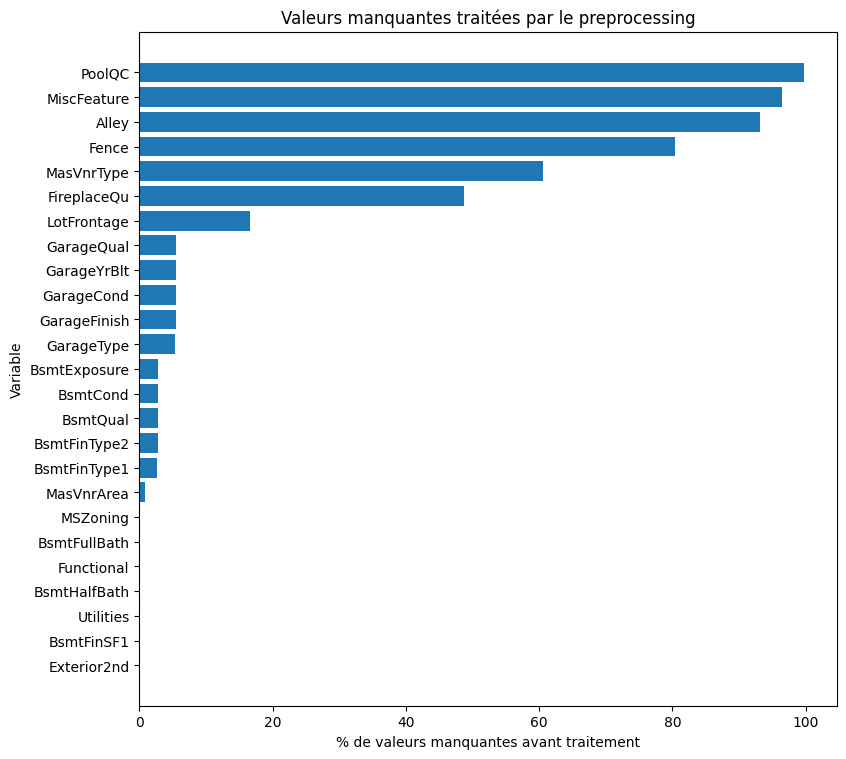

Interprétation automatique :
- Toutes les valeurs manquantes ont été traitées avec succès.
- Les variables conservées en texte seront encodées plus tard dans le pipeline.
- Les colonnes *_Ord ajoutent déjà une information numérique utile pour les qualités ordonnées.


In [15]:
# Rapport avant/après sur les valeurs manquantes.
missing_comparison = pd.DataFrame({
    'variable': missing_before_counts.index,
    'missing_avant': missing_before_counts.values,
    'missing_après': [missing_after_counts.get(c, 0) for c in missing_before_counts.index],
})
missing_comparison['missing_pct_avant'] = missing_comparison['missing_avant'] / len(features) * 100
missing_comparison = missing_comparison[missing_comparison['missing_avant'] > 0].sort_values('missing_avant', ascending=False)

display(missing_comparison.head(30))

if not missing_comparison.empty:
    top = missing_comparison.head(25)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(top))))
    ax.barh(top['variable'][::-1], top['missing_pct_avant'][::-1])
    ax.set_title('Valeurs manquantes traitées par le preprocessing')
    ax.set_xlabel('% de valeurs manquantes avant traitement')
    ax.set_ylabel('Variable')
    plt.show()

print('Interprétation automatique :')
if int(missing_after_counts.sum()) == 0:
    print('- Toutes les valeurs manquantes ont été traitées avec succès.')
else:
    print('- Attention : il reste des valeurs manquantes à corriger.')
print('- Les variables conservées en texte seront encodées plus tard dans le pipeline.')
print('- Les colonnes *_Ord ajoutent déjà une information numérique utile pour les qualités ordonnées.')

## 10. Vérification des encodages ordinaux

Les encodages ordinaux transforment des catégories ordonnées en scores numériques.

Exemple :

```text
None < Po < Fa < TA < Gd < Ex
0      1    2    3    4    5
```

In [16]:
ordinal_cols = [c for c in features_preprocessed.columns if c.endswith('_Ord')]

print('Nombre de colonnes ordinales créées :', len(ordinal_cols))
print(ordinal_cols)

ordinal_summary = pd.DataFrame({
    'variable_ordinale': ordinal_cols,
    'min': [features_preprocessed[c].min() for c in ordinal_cols],
    'max': [features_preprocessed[c].max() for c in ordinal_cols],
    'n_unique': [features_preprocessed[c].nunique() for c in ordinal_cols],
})

display(ordinal_summary)

Nombre de colonnes ordinales créées : 19
['ExterQual_Ord', 'ExterCond_Ord', 'BsmtQual_Ord', 'BsmtCond_Ord', 'HeatingQC_Ord', 'KitchenQual_Ord', 'FireplaceQu_Ord', 'GarageQual_Ord', 'GarageCond_Ord', 'PoolQC_Ord', 'BsmtExposure_Ord', 'GarageFinish_Ord', 'PavedDrive_Ord', 'CentralAir_Ord', 'LandSlope_Ord', 'LotShape_Ord', 'Functional_Ord', 'BsmtFinType1_Ord', 'BsmtFinType2_Ord']


,variable_ordinale,min,max,n_unique
0,ExterQual_Ord,2.000,5.000,4
1,ExterCond_Ord,1.000,5.000,5
2,BsmtQual_Ord,0.000,5.000,5
3,BsmtCond_Ord,0.000,4.000,5
4,HeatingQC_Ord,1.000,5.000,5
5,KitchenQual_Ord,2.000,5.000,4
6,FireplaceQu_Ord,0.000,5.000,6
7,GarageQual_Ord,0.000,5.000,6
8,GarageCond_Ord,0.000,5.000,6
9,PoolQC_Ord,0.000,5.000,4


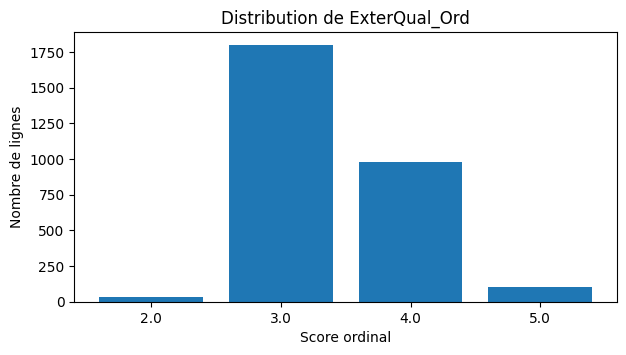

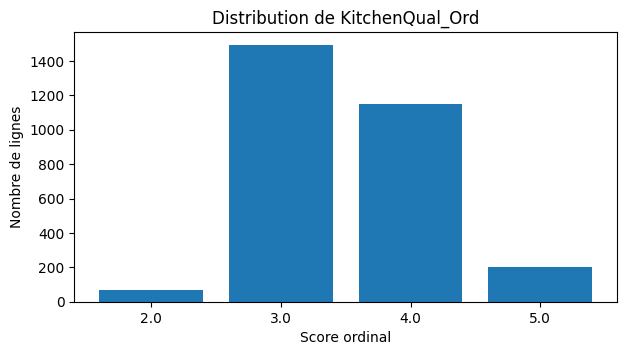

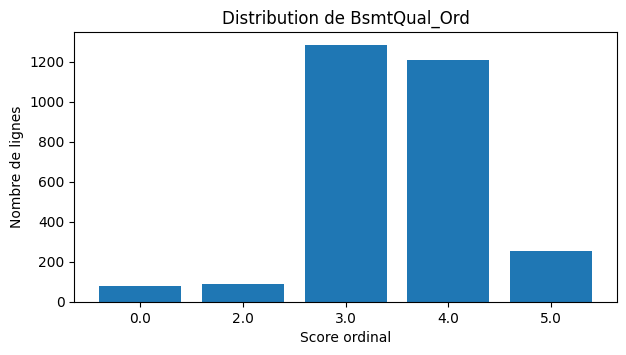

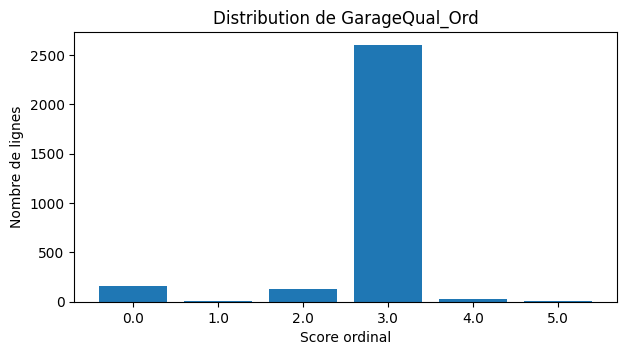

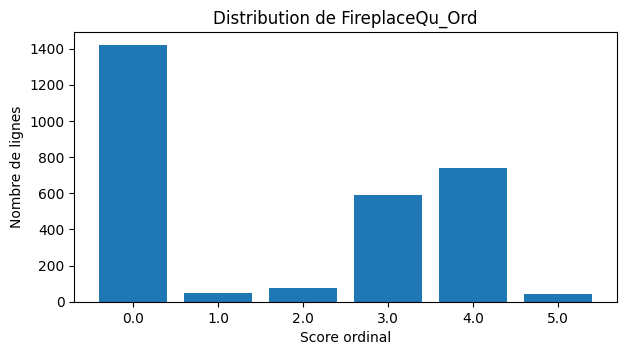

Interprétation :
- Les scores proches de 0 correspondent souvent à une absence ou à une qualité très faible.
- Les scores élevés correspondent aux meilleures qualités, souvent associées à des prix plus élevés dans l’EDA.


In [17]:
# Visualisation de quelques colonnes ordinales importantes.
important_ordinal_cols = [c for c in ['ExterQual_Ord', 'KitchenQual_Ord', 'BsmtQual_Ord', 'GarageQual_Ord', 'FireplaceQu_Ord'] if c in features_preprocessed.columns]

for c in important_ordinal_cols:
    counts = features_preprocessed[c].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f'Distribution de {c}')
    ax.set_xlabel('Score ordinal')
    ax.set_ylabel('Nombre de lignes')
    plt.show()

print('Interprétation :')
print('- Les scores proches de 0 correspondent souvent à une absence ou à une qualité très faible.')
print('- Les scores élevés correspondent aux meilleures qualités, souvent associées à des prix plus élevés dans l’EDA.')

## 11. Contrôles qualité avant sauvegarde

Avant d'écrire le fichier `.pkl`, on vérifie que les dimensions et les valeurs manquantes sont correctes.

In [18]:
X_train_stage1 = features_preprocessed.iloc[:n_train].copy()
X_test_stage1  = features_preprocessed.iloc[n_train:].copy()

checks = {
    'X_train_stage1 lignes == y lignes': X_train_stage1.shape[0] == len(y),
    'X_test_stage1 lignes == test_raw lignes': X_test_stage1.shape[0] == test_raw.shape[0],
    'Aucune valeur manquante restante': int(features_preprocessed.isna().sum().sum()) == 0,
    'Nombre de colonnes positif': features_preprocessed.shape[1] > 0,
}

checks_df = pd.DataFrame({
    'Contrôle': list(checks.keys()),
    'Résultat': ['OK' if v else 'À vérifier' for v in checks.values()]
})

display(checks_df)

for name, passed in checks.items():
    assert passed, f'Contrôle échoué : {name}'

print('Tous les contrôles qualité sont validés.')

,Contrôle,Résultat
0,X_train_stage1 lignes == y lignes,OK
1,X_test_stage1 lignes == test_raw lignes,OK
2,Aucune valeur manquante restante,OK
3,Nombre de colonnes positif,OK


Tous les contrôles qualité sont validés.


## 12. Sauvegarde du fichier Stage 1

Le notebook 03 chargera ce fichier pour continuer le pipeline avec le feature engineering.

Le nom doit rester exactement :

```text
house_prices_stage1_preprocessed.pkl
```

In [19]:
# Tout ce dont le notebook 03 a besoin est sauvegardé dans un seul fichier pickle.
stage1 = {
    'features_preprocessed': features_preprocessed,
    'y': y,
    'n_train': n_train,
    'train_ID': train_ID,
    'test_ID': test_ID,
    'test_n_rows': test_raw.shape[0],
    'DATA_DIR': DATA_DIR,
    'RANDOM_STATE': RANDOM_STATE,
    'N_SPLITS': N_SPLITS,
    'LINEAR_CV_FOLDS': LINEAR_CV_FOLDS,
    'STRATIFIED_PRICE_FOLDS': STRATIFIED_PRICE_FOLDS,
    'OPTUNA_N_TRIALS': OPTUNA_N_TRIALS,
    'OUTLIER_STRATEGY': 'GrLivArea > 4000 and SalePrice < 200000',
}

# Sauvegarde locale dans le dossier courant.
stage1_path = Path('house_prices_stage1_preprocessed.pkl')
pd.to_pickle(stage1, stage1_path)

print('Fichier Stage 1 sauvegardé ici :')
print(stage1_path.resolve())

display(features_preprocessed.head())

Fichier Stage 1 sauvegardé ici :
C:\Users\souma\OneDrive\Bureau\proj ML\projet\final\house_prices_stage1_preprocessed.pkl


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,ExterQual_Ord,ExterCond_Ord,BsmtQual_Ord,BsmtCond_Ord,HeatingQC_Ord,KitchenQual_Ord,FireplaceQu_Ord,GarageQual_Ord,GarageCond_Ord,PoolQC_Ord,BsmtExposure_Ord,GarageFinish_Ord,PavedDrive_Ord,CentralAir_Ord,LandSlope_Ord,LotShape_Ord,Functional_Ord,BsmtFinType1_Ord,BsmtFinType2_Ord
0,60,RL,65.000,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706.000,Unf,0.000,150.000,856.000,GasA,Ex,Y,SBrkr,856,854,0,1710,1.000,0.000,2,1,3,1,Gd,8,Typ,0,None,Attchd,"2,003.000",RFn,2.000,548.000,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,4.000,3.000,4.000,3.000,5.000,4.000,0.000,3.000,3.000,0.000,1.000,2.000,2.000,1.000,0.000,3.000,7.000,6.000,1.000
1,20,RL,80.000,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.000,Unf,0.000,284.000,"1,262.000",GasA,Ex,Y,SBrkr,1262,0,0,1262,0.000,1.000,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.000",RFn,2.000,460.000,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,3.000,3.000,4.000,3.000,5.000,3.000,3.000,3.000,3.000,0.000,4.000,2.000,2.000,1.000,0.000,3.000,7.000,5.000,1.000
2,60,RL,68.000,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.000,Unf,0.000,434.000,920.000,GasA,Ex,Y,SBrkr,920,866,0,1786,1.000,0.000,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.000",RFn,2.000,608.000,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,4.000,3.000,4.000,3.000,5.000,4.000,3.000,3.000,3.000,0.000,2.000,2.000,2.000,1.000,0.000,2.000,7.000,6.000,1.000
3,70,RL,60.000,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216.000,Unf,0.000,540.000,756.000,GasA,Gd,Y,SBrkr,961,756,0,1717,1.000,0.000,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.000",Unf,3.000,642.000,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,3.000,3.000,3.000,4.000,4.000,4.000,4.000,3.000,3.000,0.000,1.000,1.000,2.000,1.000,0.000,2.000,7.000,5.000,1.000
4,60,RL,84.000,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655.000,Unf,0.000,490.000,"1,145.000",GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.000,0.000,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.000",RFn,3.000,836.000,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,4.000,3.000,4.000,3.000,5.000,4.000,3.000,3.000,3.000,0.000,3.000,2.000,2.000,1.000,0.000,2.000,7.000,6.000,1.000


## 13. Synthèse du preprocessing

À ce stade, nous avons obtenu un dataset :

- sans valeurs manquantes ;
- avec une cible transformée en log ;
- avec les outliers évidents retirés ;
- avec des catégories importantes converties en scores ordinaux ;
- prêt pour le feature engineering avancé.

Prochaine étape :

```text
03_feature_engineering_house_prices_local.ipynb
```